In [ ]:
!pip install opendatasets

import opendatasets as od
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
od.download("https://www.kaggle.com/datasets/ashishmotwani/tomato")

print("Download complete")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: hege00
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ashishmotwani/tomato


100%|██████████| 1.37G/1.37G [01:17<00:00, 19.1MB/s]



Download complete


In [ ]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

TRAIN_DIR = "tomato/train"
VALID_DIR = "tomato/valid"

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.5,
    subset="training",
    seed=42
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.5,
    subset="validation",
    seed=42
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("\n--- PODZIAŁ ZBIORÓW DANYCH ---")
print(f"Liczba batchów w Train:      {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Liczba batchów w Validation: {tf.data.experimental.cardinality(val_ds_raw).numpy()}")
print(f"Liczba batchów w Test:       {tf.data.experimental.cardinality(test_ds_raw).numpy()}")
print(f"\nLiczba klas: {NUM_CLASSES}")
for i, name in enumerate(class_names):
    print(f"  Klasa {i}: {name}")

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)

Found 25851 files belonging to 11 classes.
Found 6683 files belonging to 11 classes.
Using 3342 files for training.
Found 6683 files belonging to 11 classes.
Using 3341 files for validation.

--- PODZIAŁ ZBIORÓW DANYCH ---
Liczba batchów w Train:      808
Liczba batchów w Validation: 105
Liczba batchów w Test:       105

Liczba klas: 11
  Klasa 0: Bacterial_spot
  Klasa 1: Early_blight
  Klasa 2: Late_blight
  Klasa 3: Leaf_Mold
  Klasa 4: Septoria_leaf_spot
  Klasa 5: Spider_mites Two-spotted_spider_mite
  Klasa 6: Target_Spot
  Klasa 7: Tomato_Yellow_Leaf_Curl_Virus
  Klasa 8: Tomato_mosaic_virus
  Klasa 9: healthy
  Klasa 10: powdery_mildew


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.1),
])

In [ ]:
def build_tomato_cnn(input_shape=(224, 224, 3), num_classes=11):
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),

        # Data Augmentation and Normalization
        data_augmentation,
        layers.Rescaling(1./255),

        # 1st Convolutional Layer
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # 2nd Convolutional Layer
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # 3rd Convolutional Layer
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Flatten to 1 Vector
        layers.Flatten(),

        # Fully Connected Layer
        layers.Dense(128, activation='relu'),

        # Dropout
        layers.Dropout(0.5),

        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

model = build_tomato_cnn(num_classes=len(class_names))

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Displaying Model Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,379 (42.61 MB)

 Trainable params: 11,170,379 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 20

# Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
print("Ladies and gentlemen welcome aboard delta airlines flight 2998")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Ladies and gentlemen welcome aboard delta airlines flight 2998
Epoch 1/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.3210 - loss: 1.8875 - val_accuracy: 0.5655 - val_loss: 1.1984
Epoch 2/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5244 - loss: 1.3232 - val_accuracy: 0.6670 - val_loss: 0.9065
Epoch 3/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5901 - loss: 1.1412 - val_accuracy: 0.7029 - val_loss: 0.8304
Epoch 4/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6259 - loss: 1.0389 - val_accuracy: 0.6577 - val_loss: 0.9490
Epoch 5/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6524 - loss: 0.9726 - val_accuracy: 0.7253 - val_loss: 0.7714
Epoch 6/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6685 - loss: 0.9266 - val_accuracy: 0.7241 - val_loss: 0.7751
Epoch 7/20
808/808 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6876 - loss: 0.8681 - val_accuracy: 0.7516 - val_loss: 0.7021
Epoch 8/20
808/808 ━━━━━━━━━━━━

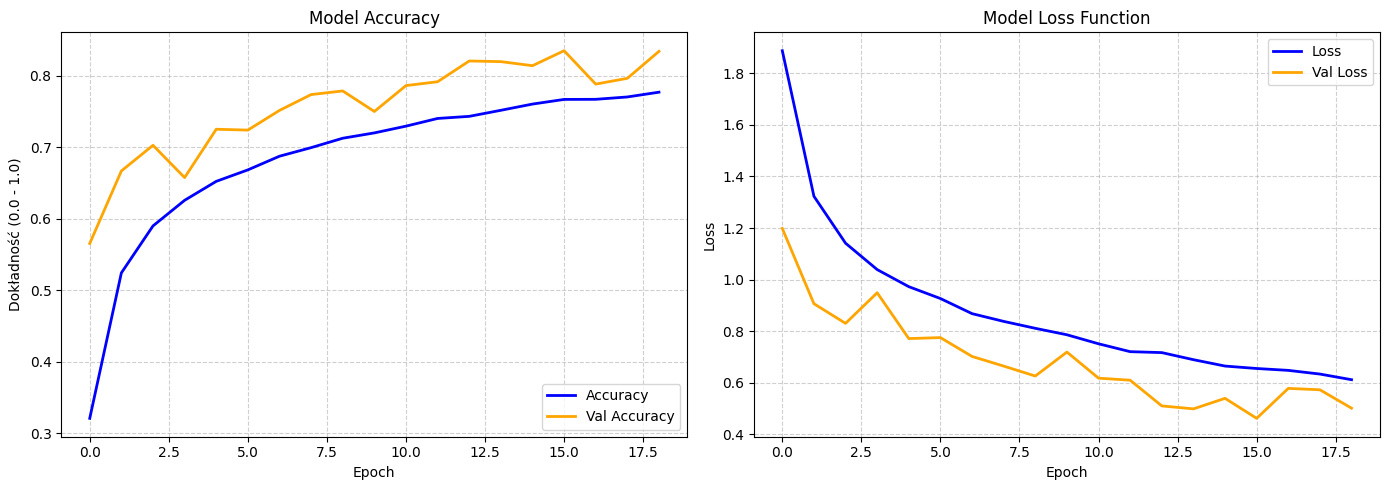

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Val Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('Dokładność (0.0 - 1.0)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Val Loss', color='orange', linewidth=2)
plt.title('Model Loss Function', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"Test loss     : {test_loss:.4f}")

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8393 - loss: 0.4546

Test accuracy : 0.8393 (83.9%)
Test loss     : 0.4546


                                      precision    recall  f1-score   support

                      Bacterial_spot      0.832     0.759     0.794       345
                        Early_blight      0.765     0.861     0.810       330
                         Late_blight      0.672     0.765     0.715       404
                           Leaf_Mold      0.980     0.774     0.864       371
                  Septoria_leaf_spot      0.806     0.748     0.776       361
Spider_mites Two-spotted_spider_mite      0.935     0.832     0.880       208
                         Target_Spot      0.835     0.910     0.871       233
       Tomato_Yellow_Leaf_Curl_Virus      0.934     0.960     0.947       251
                 Tomato_mosaic_virus      0.918     0.949     0.933       295
                             healthy      0.907     0.964     0.935       416
                      powdery_mildew      0.691     0.669     0.680       127

                            accuracy                          

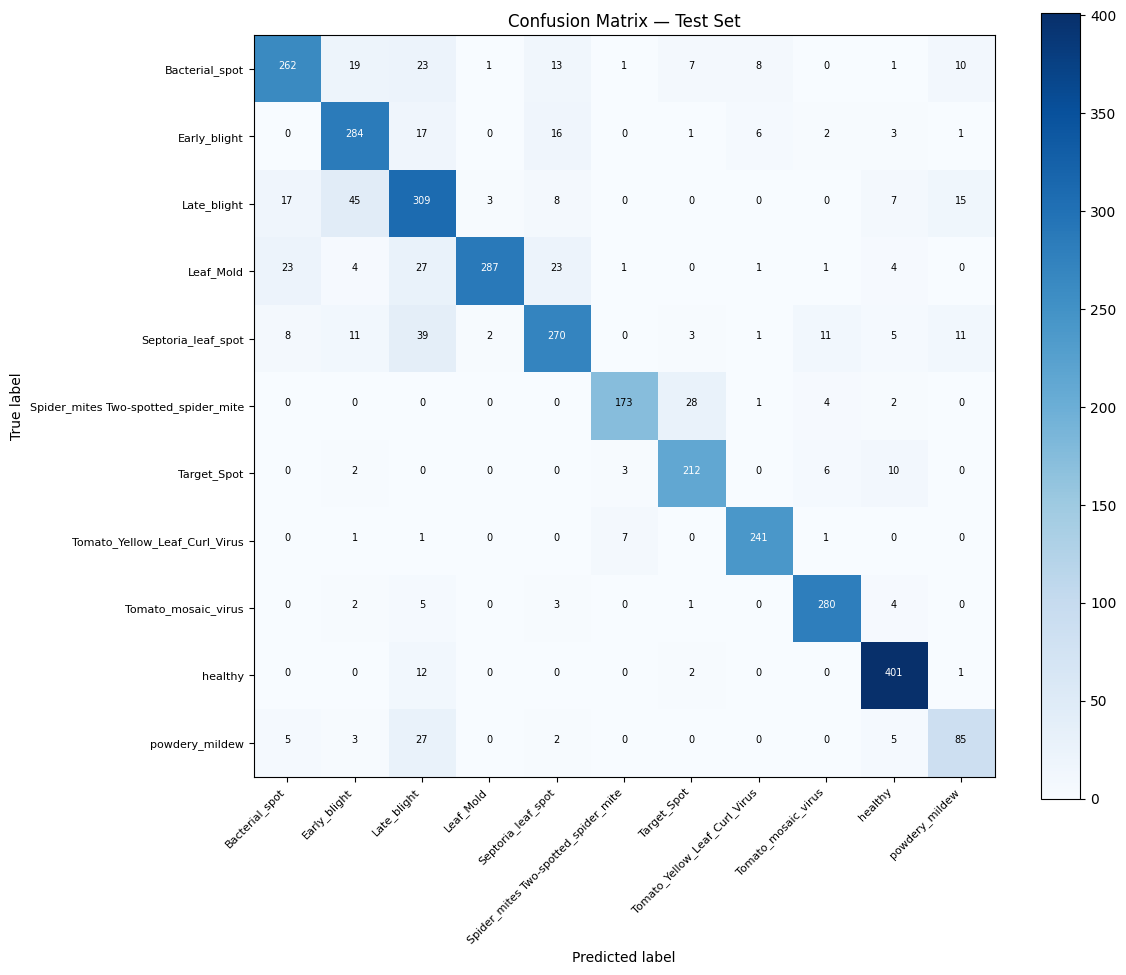

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import numpy as np

# Generate predictions

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar()
tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, class_names, rotation=45, ha="right", fontsize=8)
plt.yticks(tick_marks, class_names, fontsize=8)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("Confusion Matrix — Test Set")

# Annotate cells
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, str(cm[i, j]), horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black", fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
model.save("tomato_disease_krzyśkowy.keras")
print("Model saved!")

Model saved!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
